# Module 2 Milestone: Train a network end to end

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)
np.random.seed(0)


## 1. Load and split the data

In [14]:
X, y = load_wine(return_X_y=True)

# First keep 20% aside as the final test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

# Split the remaining data into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=0,
    stratify=y_train_val
)

print("train size:", len(X_train))
print("validation size:", len(X_val))
print("test size:", len(X_test))

train size: 106
validation size: 36
test size: 36


## 2. Scale the features

In [15]:
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler for validation and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("train shape:", X_train_scaled.shape)
print("validation shape:", X_val_scaled.shape)
print("test shape:", X_test_scaled.shape)

train shape: (106, 13)
validation shape: (36, 13)
test shape: (36, 13)


## 3. Convert the data to PyTorch tensors

In [16]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

print("training tensor:", X_train_t.shape)
print("training labels:", y_train_t.shape)

training tensor: torch.Size([106, 13])
training labels: torch.Size([106])


## 4. Define the neural network

In [17]:
torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(13, 32),
    nn.ReLU(),
    nn.Linear(32, 3)
)

print(model)

Sequential(
  (0): Linear(in_features=13, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=3, bias=True)
)


## 5. Set up the loss and optimizer

In [18]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=0.001
)

print("Loss:", loss_fn)
print("Optimizer: Adam")

Loss: CrossEntropyLoss()
Optimizer: Adam


## 6. Train the model and record the losses

In [19]:
epochs = 100

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0
best_state = None

for epoch in range(epochs):

    model.train()

    total_train_loss = 0.0

    for batch_X, batch_y in train_loader:

        pred = model(batch_X)
        loss = loss_fn(pred, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * len(batch_X)

    average_train_loss = total_train_loss / len(train_dataset)
    train_losses.append(average_train_loss)

    # Validation
    model.eval()

    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t).item()

    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {
            key: value.clone()
            for key, value in model.state_dict().items()
        }

print("training complete")
print("best epoch:", best_epoch)
print(f"best validation loss: {best_val_loss:.4f}")

training complete
best epoch: 44
best validation loss: 0.0067


## 7. Restore the model from the best validation epoch

In [20]:
model.load_state_dict(best_state)

print(f"restored weights from epoch {best_epoch}")

restored weights from epoch 44


## 8. Plot the learning curves

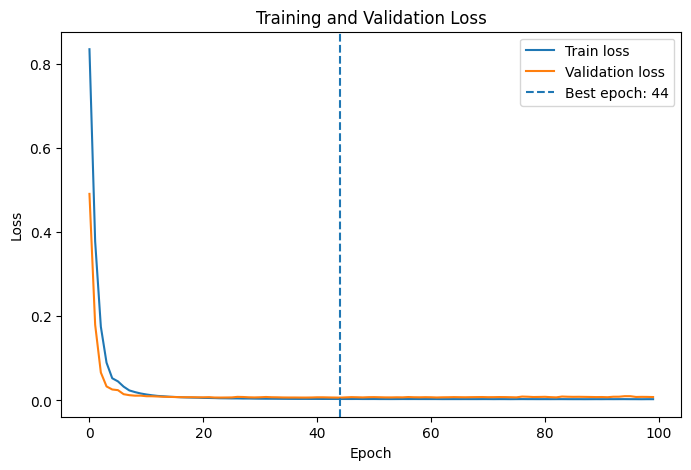

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch: {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

## 9. Evaluate train and test accuracy

In [22]:
model.eval()

with torch.no_grad():

    train_logits = model(X_train_t)
    train_predictions = train_logits.argmax(dim=1)

    test_logits = model(X_test_t)
    test_predictions = test_logits.argmax(dim=1)

train_accuracy = (
    (train_predictions == y_train_t)
    .float()
    .mean()
    .item()
)

test_accuracy = (
    (test_predictions == y_test_t)
    .float()
    .mean()
    .item()
)

print(f"train accuracy: {train_accuracy:.3f}")
print(f"test accuracy: {test_accuracy:.3f}")
print(f"train-test gap: {train_accuracy - test_accuracy:.3f}")

train accuracy: 1.000
test accuracy: 1.000
train-test gap: 0.000


## 10. Interpretation

The network learned to classify the three wine classes very well, achieving a training accuracy of 1.000 and a test accuracy of 1.000. The validation loss reached its lowest value around epoch 44, and the train-test accuracy gap was 0.000, showing little evidence of overfitting and good generalization to unseen data.

## 11. Save the trained model weights

In [23]:
torch.save(
    model.state_dict(),
    "wine_model_weights.pth"
)

print("saved wine_model_weights.pth")

saved wine_model_weights.pth
